In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')


In [7]:
#Loading the dataset
conn = sqlite3.connect('inventory.db')

#fetching vendor summary data
df=pd.read_sql_query("select * from vendor_sales_summary",conn)
df.head()


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,72845.0,2616356.55,377521.53,133843.95,68601.68,-1194895.05,-45.670192,0.502102,0.686482
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,74631.0,2255799.65,313785.51,137126.40,144929.24,-1548241.57,-68.633824,0.454962,0.593001
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,99026.0,2421668.24,261693.64,181951.49,123780.22,-996635.44,-41.154912,0.528401,0.708442
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,101675.0,2294079.25,237136.03,186819.86,257032.07,-967118.69,-42.157161,0.504135,0.703447
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,70915.0,2200482.85,302798.19,130298.37,257032.07,-822723.16,-37.388301,0.513471,0.727864


Exploratory Data Analysis
* Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.
* In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.


In [8]:
#summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,1.548279e+03,5712.781605,0.00,10.750000,99.000000,880.250000,1.807630e+05
TotalSalesDollars,10692.0,2.106734e+04,85020.485895,0.00,182.605000,2111.765000,13481.497500,2.616357e+06
TotalSalesPrice,10692.0,9.650372e+03,24262.437530,0.00,49.987500,1072.940000,7621.370000,3.775215e+05


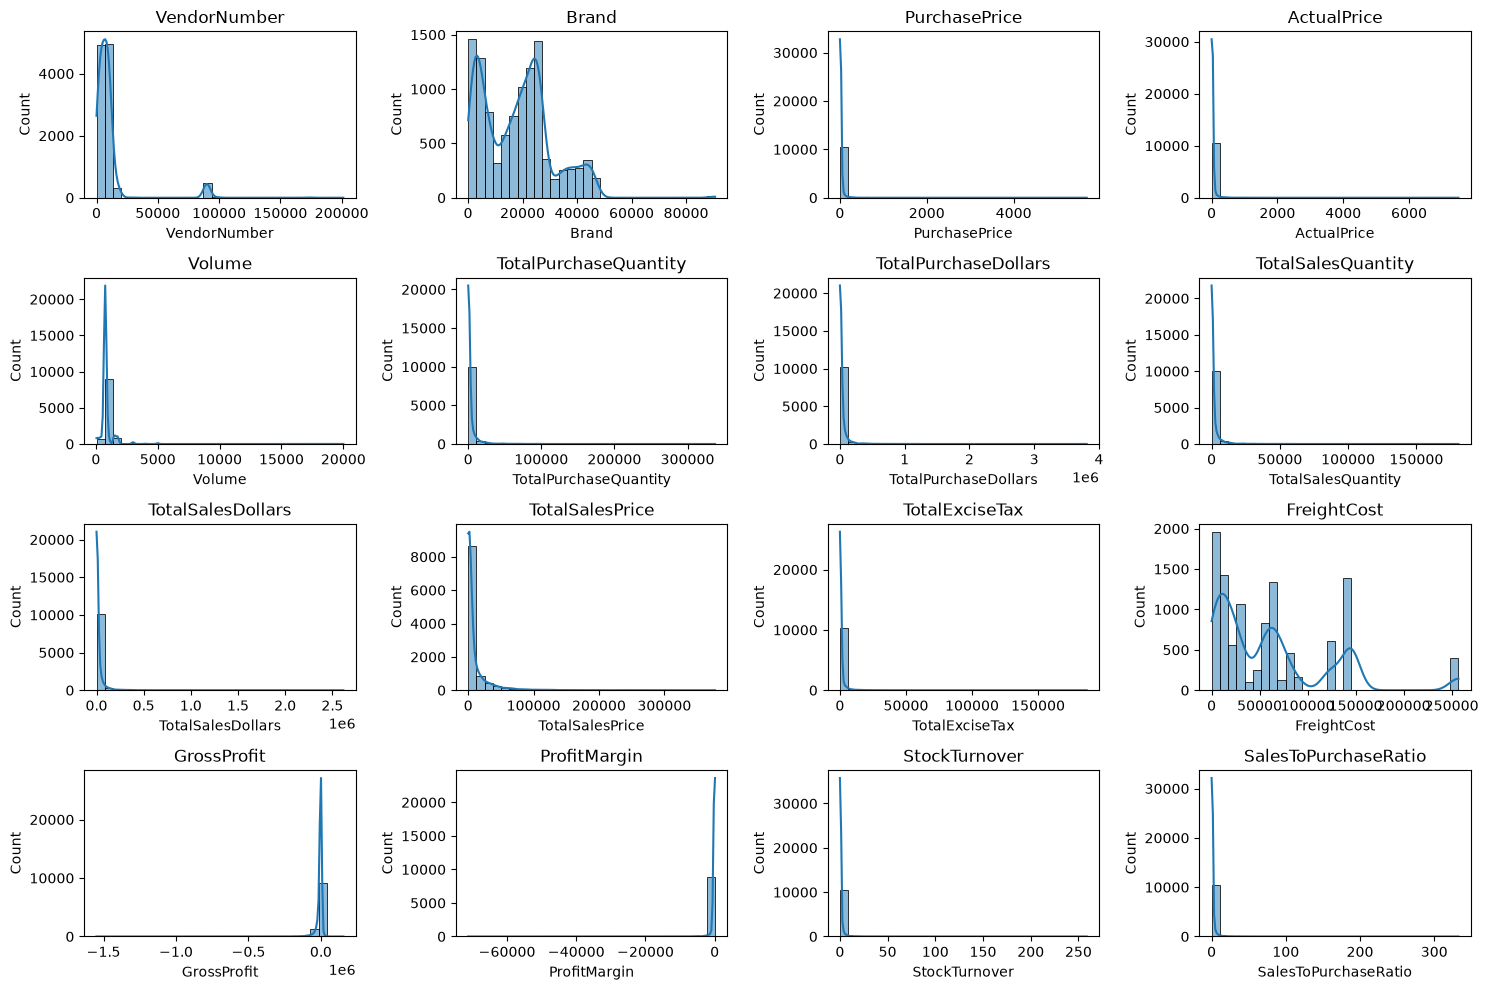

In [9]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

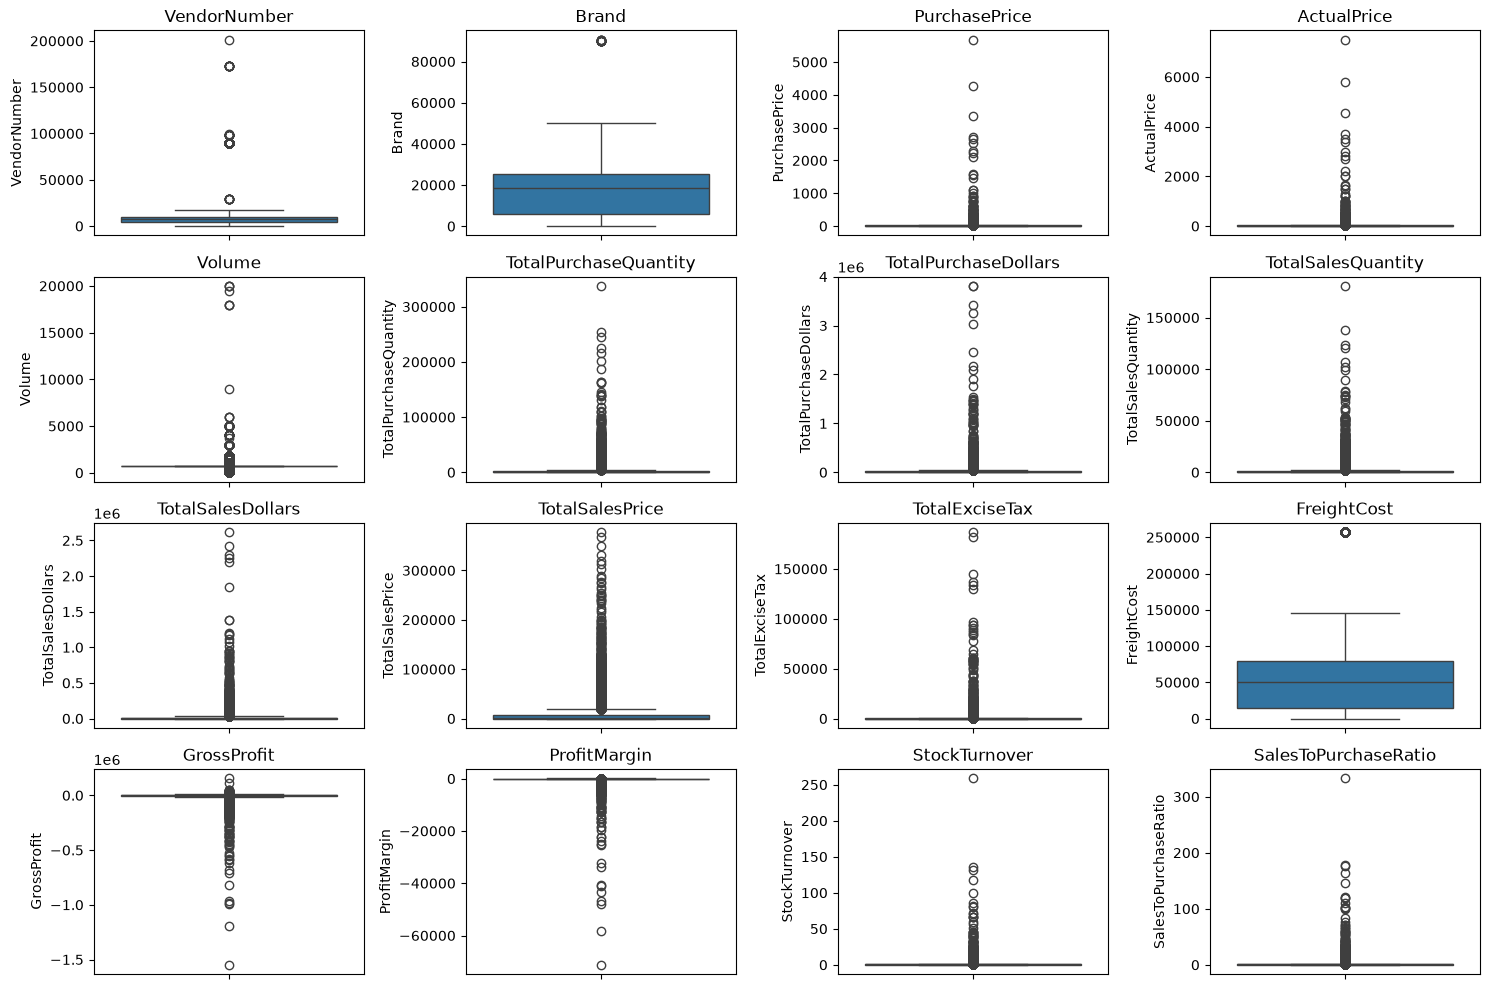

In [10]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  # Adjust grid layout as needed
    sns.boxplot(y = df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### Summary Statistics Insights:

**Negative & Zero Values:**

* **Gross Profit:** Minimum value is **-52,002.78**, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.
* **Profit Margin:** Has a minimum of **-∞**, which suggests cases where revenue is zero or even lower than costs.
* **Total Sales Quantity & Sales Dollars:** Minimum values are **0**, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

**Outliers Indicated by High Standard Deviations:**

* **Purchase & Actual Prices:** The max values (**5,681.81 & 7,499.99**) are significantly higher than the mean (**24.39 & 35.64**), indicating potential premium products.
* **Freight Cost:** Huge variation, from **0.09 to 257,032.07**, suggests logistics inefficiencies or bulk shipments.
* **Stock Turnover:** Ranges from **0 to 274.5**, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that **sold quantity for that product is higher than purchased quantity due to either sales of old stock.**


In [11]:
# let's filter the data by removing inconsistencies
df = pd.read_sql_query("""SELECT *
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""", conn)

In [12]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,4425,MARTIGNETTI COMPANIES,23143,Bogle Chard,4.65,6.79,750.0,74342,345690.30,45789.0,356047.11,53862.65,5142.48,144929.24,10356.81,2.908831,0.615924,1.029960
1,4425,MARTIGNETTI COMPANIES,6595,Bogle Merlot,4.48,6.95,750.0,63188,283082.24,37168.0,290536.32,59569.63,4170.98,144929.24,7454.08,2.565628,0.588213,1.026332
2,1128,BROWN-FORMAN CORP,5299,Southern Comfort,15.26,21.99,1750.0,15196,231890.96,15234.0,349220.66,136423.80,27990.82,68601.68,117329.70,33.597583,1.002501,1.505969
3,3252,E & J GALLO WINERY,33149,Alamos Ridge Malbec Mendoza,4.79,8.99,750.0,43995,210736.05,25560.0,214508.36,56016.76,2864.48,61966.91,3772.31,1.758584,0.580975,1.017901
4,4425,MARTIGNETTI COMPANIES,6983,J Lohr Seven Oaks Cab Svgn,8.27,11.99,750.0,23576,194973.52,12728.0,207364.72,68995.11,1423.62,144929.24,12391.20,5.975558,0.539871,1.063553
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2607,3960,DIAGEO NORTH AMERICA INC,2626,Crown Royal Apple,1.42,1.99,50.0,2,2.84,12.0,23.88,1.99,0.63,257032.07,21.04,88.107203,6.000000,8.408451
2608,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
2609,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,128.0,62.72,0.98,6.72,50293.62,60.38,96.269133,21.333333,26.803419
2610,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,35.0,69.65,33.83,7.35,257032.07,68.18,97.889447,35.000000,47.380952


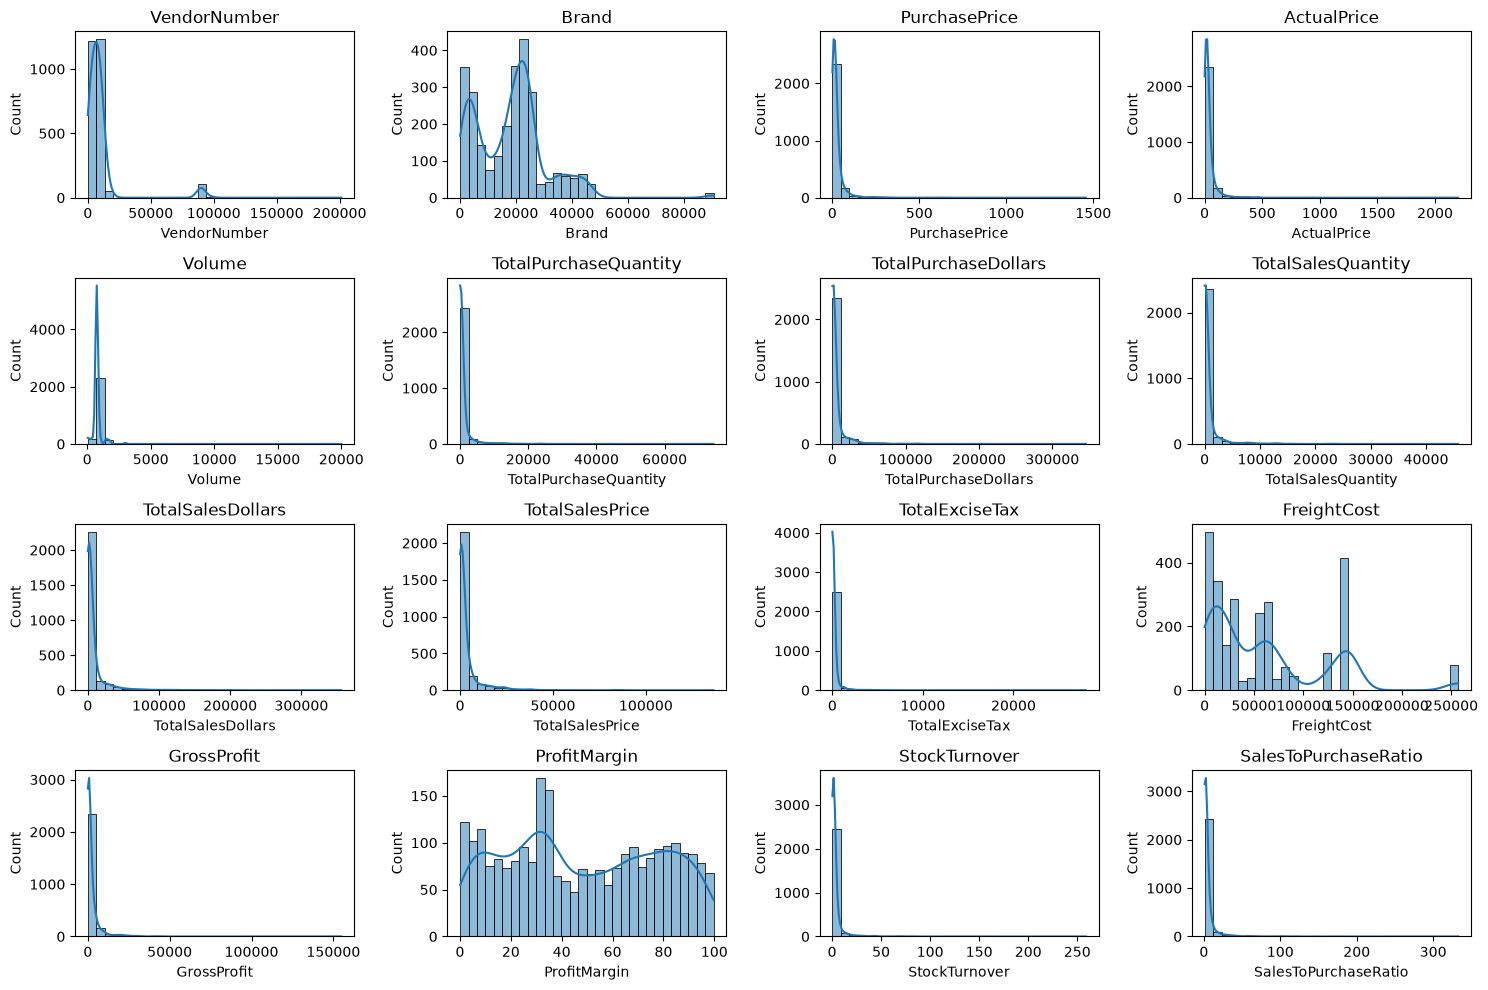

In [13]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

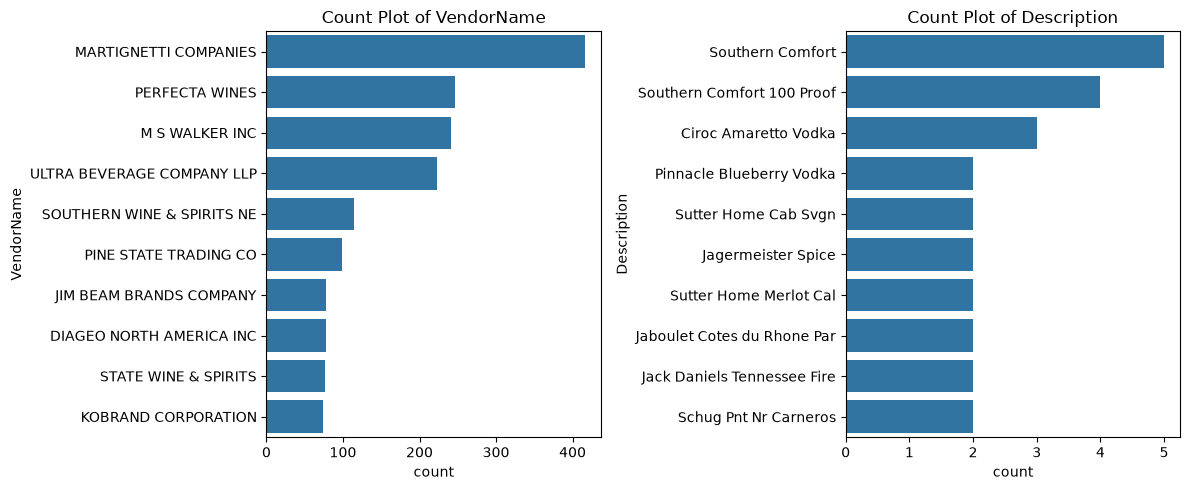

In [14]:
# Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])  # Top 10 categories
    plt.title(f"Count Plot of {col}")

plt.tight_layout()
plt.show()

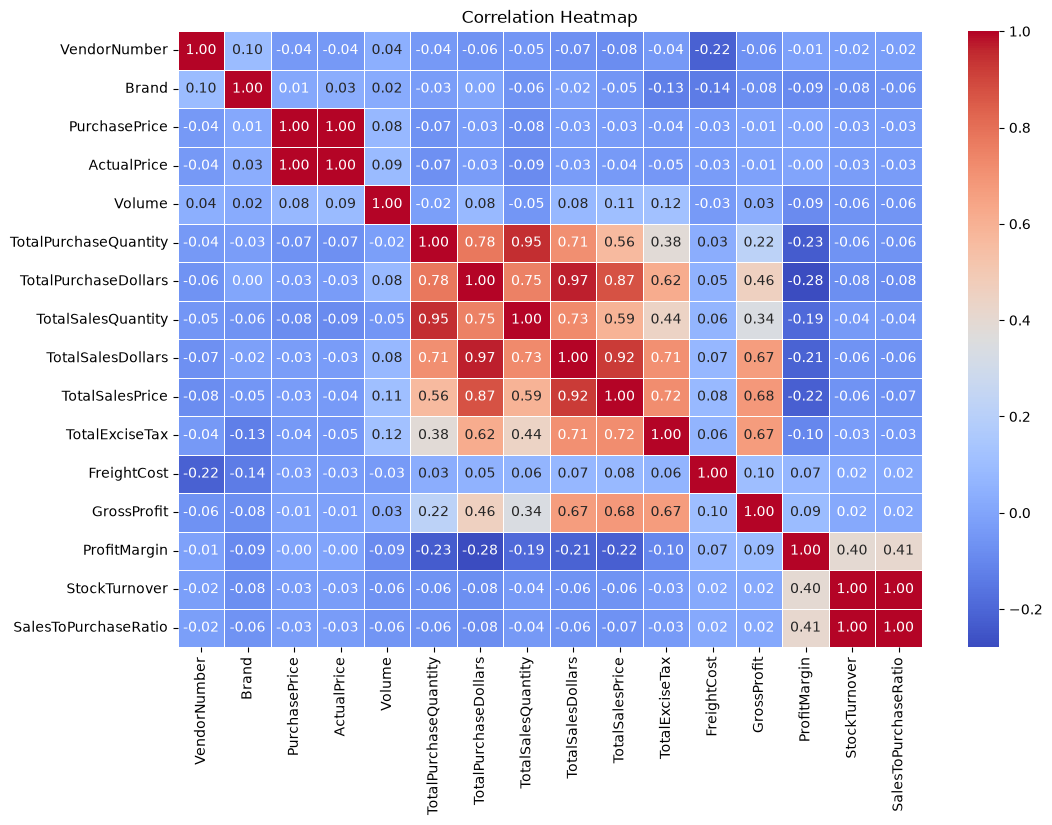

In [15]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Insights

* **PurchasePrice** has weak correlations with **TotalSalesDollars (-0.012)** and **GrossProfit (-0.016)**, suggesting that price variations do not significantly impact sales revenue or profit.
* There is a **very strong correlation between TotalPurchaseQuantity and TotalSalesQuantity (0.999)**, indicating that purchase volume closely tracks sales volume.
* The **negative correlation between ProfitMargin and TotalSalesPrice (-0.179)** suggests that as sales price increases, profit margins tend to decrease, possibly due to competitive pricing pressures.
* **StockTurnover** has weak negative correlations with both **GrossProfit (-0.038)** and **ProfitMargin (-0.055)**, indicating that faster inventory turnover does not necessarily lead to higher profitability.


Data Analysis
Identify Brands that needs Promotional or Pricing Adjustments which exhibit lower sales performance but higher profit margins.

In [18]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',
    'ProfitMargin': 'mean'
}).reset_index()

In [21]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [22]:
low_sales_threshold 

np.float64(269.73)

In [23]:
high_margin_threshold

np.float64(83.9529800709503)

In [24]:
# Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]

print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
834,Crown Royal Apple,23.88,88.107203
2382,Tracia Syrah,44.94,88.495772
209,Basilica Amaretto,47.45,85.079031
944,Dr McGillicuddy's Apple Pie,62.72,96.269133
2061,Sauza Sparkling Margarita,62.91,91.448100
2313,The Club Strawbry Margarita,69.65,97.889447
1911,Promesses de France CdRhone,71.91,92.337644
2312,The Club Mudslide,83.58,91.325676
2342,Three Olives Grape Vodka,85.14,99.166079
116,Aresti Pnt Nr Curico Vly,94.81,96.540449


In [26]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<10000] #for better visualization

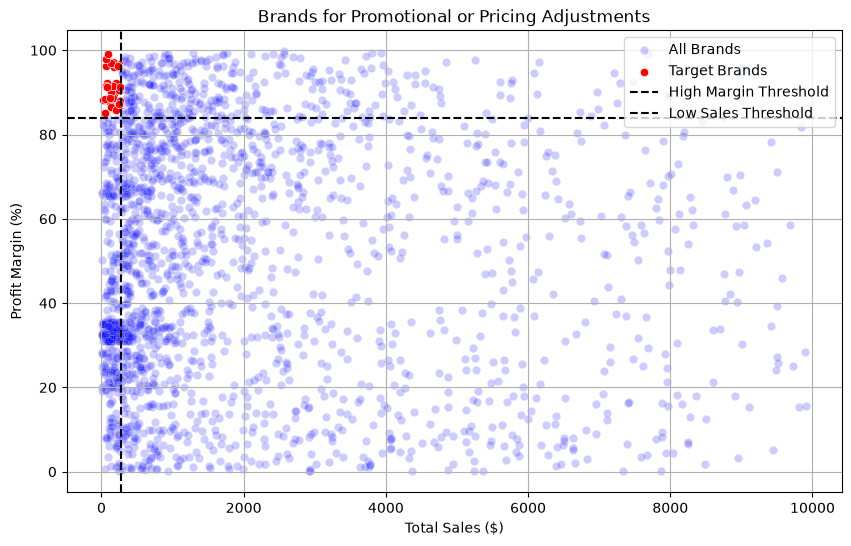

In [27]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=brand_performance,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='blue',
    label='All Brands',
    alpha=0.2
)

sns.scatterplot(
    data=target_brands,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='red',
    label='Target Brands'
)

plt.axhline(
    high_margin_threshold,
    linestyle='--',
    color='black',
    label='High Margin Threshold'
)

plt.axvline(
    low_sales_threshold,
    linestyle='--',
    color='black',
    label='Low Sales Threshold'
)

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

Which vendors and brands demonstrate the highest sales performance?

In [30]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [31]:
# Top Vendors & Brands by Sales Performance
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)

top_vendors

VendorName
MARTIGNETTI COMPANIES         4078377.07
ULTRA BEVERAGE COMPANY LLP    1801417.03
BROWN-FORMAN CORP             1093680.10
PERFECTA WINES                1059848.11
SOUTHERN WINE & SPIRITS NE     877175.49
M S WALKER INC                 864882.36
JIM BEAM BRANDS COMPANY        841877.29
TREASURY WINE ESTATES          781540.70
E & J GALLO WINERY             765279.99
CONSTELLATION BRANDS INC       737998.00
Name: TotalSalesDollars, dtype: float64

In [32]:
top_brands

Description
Southern Comfort                600063.27
Bogle Chard                     356047.11
Jim Beam Traveler               340530.32
Bogle Merlot                    290536.32
Alamos Ridge Malbec Mendoza     214508.36
J Lohr Seven Oaks Cab Svgn      207364.72
Kris Pnt Grigio Alto Adige      183822.09
Black Box Merlot Cal            161809.43
Ch St Jean Chard California     158566.57
Zaccagnini Montepulciano Rsv    150878.81
Name: TotalSalesDollars, dtype: float64

In [33]:
top_brands.apply(lambda x : format_dollars(x))

Description
Southern Comfort                600.06K
Bogle Chard                     356.05K
Jim Beam Traveler               340.53K
Bogle Merlot                    290.54K
Alamos Ridge Malbec Mendoza     214.51K
J Lohr Seven Oaks Cab Svgn      207.36K
Kris Pnt Grigio Alto Adige      183.82K
Black Box Merlot Cal            161.81K
Ch St Jean Chard California     158.57K
Zaccagnini Montepulciano Rsv    150.88K
Name: TotalSalesDollars, dtype: str

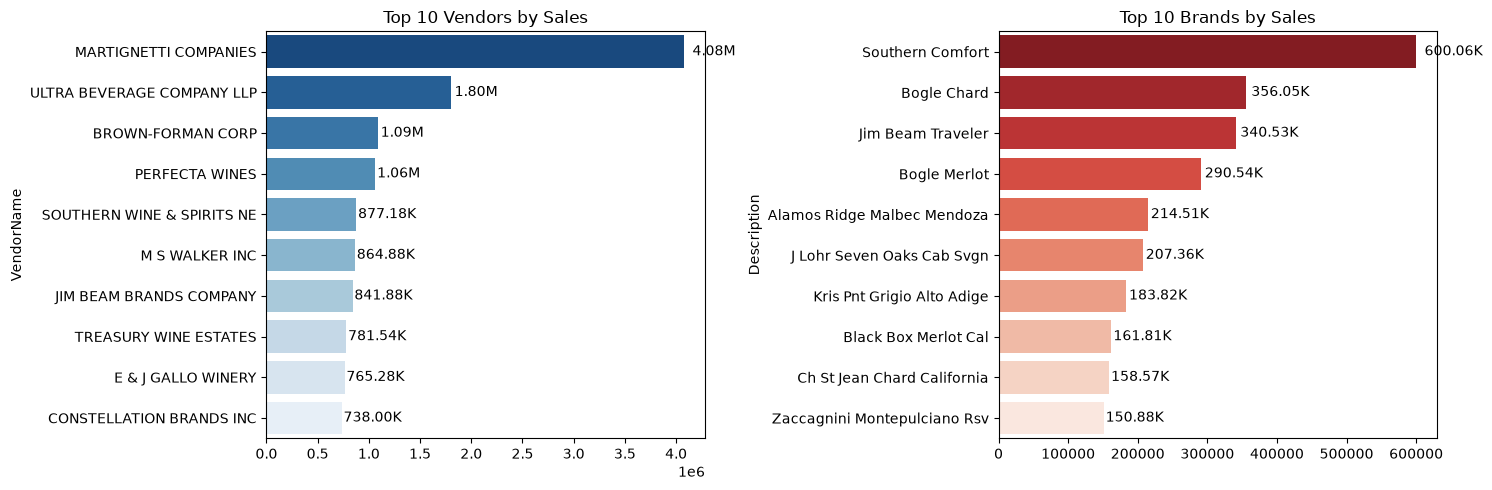

In [34]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(
    y=top_vendors.index,
    x=top_vendors.values,
    palette="Blues_r"
)
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(
    y=top_brands.index.astype(str),
    x=top_brands.values,
    palette="Reds_r"
)
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

plt.tight_layout()
plt.show()

Which vendors contribute the most to total purchase dollars?

In [45]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit': 'sum',
    'TotalSalesDollars': 'sum'
}).reset_index()
vendor_performance.shape

(93, 4)

In [52]:
vendor_performance['PurchaseContributions%'] = (vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum())*100


In [53]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContributions%', ascending = False),2)

In [54]:
# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)

top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)

top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContributions%
43,MARTIGNETTI COMPANIES,2.84M,1.23M,4.08M,20.53
83,ULTRA BEVERAGE COMPANY LLP,1.09M,709.37K,1.80M,7.89
7,BROWN-FORMAN CORP,737.59K,356.09K,1.09M,5.33
53,PERFECTA WINES,732.74K,327.11K,1.06M,5.29
80,TREASURY WINE ESTATES,726.45K,55.09K,781.54K,5.25
70,SOUTHERN WINE & SPIRITS NE,688.68K,188.50K,877.18K,4.97
22,E & J GALLO WINERY,651.07K,114.21K,765.28K,4.70
13,CONSTELLATION BRANDS INC,604.08K,133.91K,738.00K,4.36
40,M S WALKER INC,499.82K,365.06K,864.88K,3.61
33,JIM BEAM BRANDS COMPANY,484.63K,357.25K,841.88K,3.50


In [66]:
vendor_performance['Cumulative_Contribution%'] = (
    vendor_performance['PurchaseContributions%'].cumsum()
)
top_vendors = vendor_performance.head(10)


In [67]:
print(top_vendors.columns.tolist())

['VendorName', 'TotalPurchaseDollars', 'GrossProfit', 'TotalSalesDollars', 'PurchaseContributions%', 'Cumulative_Contribution%']


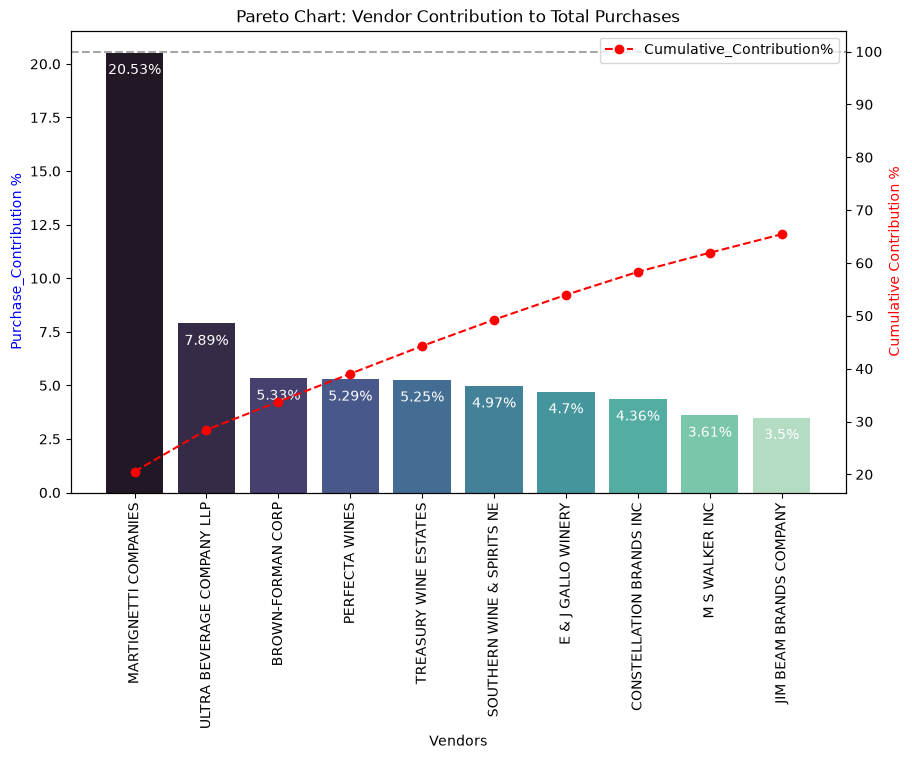

In [68]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(
    x=top_vendors['VendorName'],
    y=top_vendors['PurchaseContributions%'],
    palette="mako",
    ax=ax1
)

for i, value in enumerate(top_vendors['PurchaseContributions%']):
    ax1.text(
        i,
        value - 1,
        str(value) + '%',
        ha='center',
        fontsize=10,
        color='white'
    )

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()

ax2.plot(
    top_vendors['VendorName'],
    top_vendors['Cumulative_Contribution%'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative_Contribution%'
)

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)

ax1.set_ylabel('Purchase_Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(
    y=100,
    color='gray',
    linestyle='dashed',
    alpha=0.7
)

ax2.legend(loc='upper right')

plt.show()

How much of total procurement is dependent on the top vendors?

In [71]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContributions%'].sum(),2)}%")

Total Purchase Contribution of top 10 vendors is 65.43%


Text(0.5, 1.0, "Top 10 Vendor's Purchase Contribution (%)")

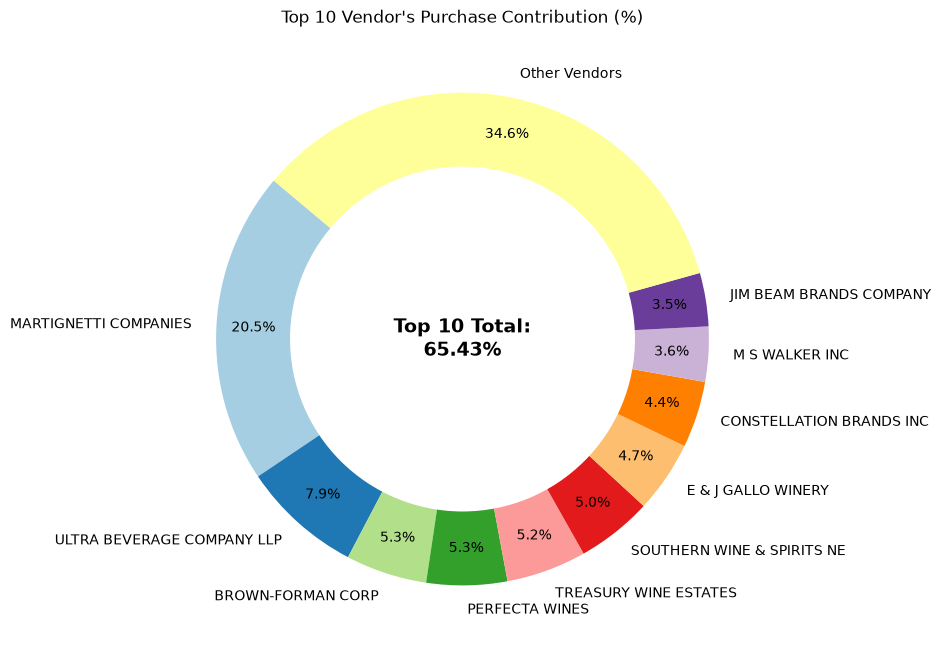

In [73]:
vendors = list(top_vendors['VendorName'].values)

purchase_contributions = list(top_vendors['PurchaseContributions%'].values)

total_contribution = sum(purchase_contributions)

remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(
    0, 0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

plt.title("Top 10 Vendor's Purchase Contribution (%)")

Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost savings?

In [75]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']


In [77]:
df['OrderSize'] = pd.qcut(df['TotalPurchaseQuantity'], q=3, labels=['Small', 'Medium', 'Large'])

In [80]:
df[['OrderSize','TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,Large,74342
1,Large,63188
2,Large,15196
3,Large,43995
4,Large,23576
...,...,...
2607,Small,2
2608,Small,2
2609,Small,6
2610,Small,1


In [82]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,43.104859
Medium,22.606172
Large,11.504324


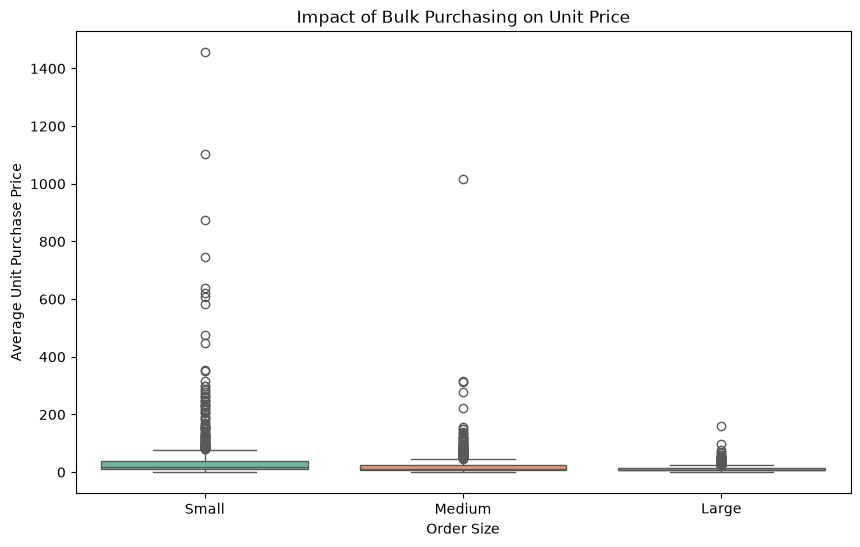

In [83]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="OrderSize",
    y="UnitPurchasePrice",
    palette="Set2"
)

plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

### Insights

* Vendors purchasing in bulk (**Large Order Size**) get the lowest unit price of **$10.78 per unit**, potentially allowing higher margins if inventory is managed efficiently.
* The price difference between **Small and Large orders** is substantial, representing roughly a **72% reduction in unit cost**.
* This suggests that **bulk pricing strategies successfully encourage vendors to purchase larger volumes**, increasing overall sales despite the lower revenue per unit.


Which vendors have low inventory turnover, indicating excess stock and slow-oving products?

In [88]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending = True).head(10)

,StockTurnover
VendorName,
THE IMPORTED GRAPE LLC,0.558135
WINE GROUP INC,0.598256
SHAW ROSS INT L IMP LTD,0.666667
STELLAR IMPORTING CO LLC,0.674464
FABRIZIA SPIRITS LLC,0.678684
TREASURY WINE ESTATES,0.688198
PINE STATE TRADING CO,0.689960
CONSTELLATION BRANDS INC,0.692061
BRONCO WINE COMPANY,0.700000


How much capital is locked in unsold inventory per vendor, and which contribute the most to it?

In [89]:
df["UnsoldInventoryValue"] = (
    df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]
) * df["PurchasePrice"]

print(
    "Total Unsold Capital:",
    format_dollars(df["UnsoldInventoryValue"].sum())
)

Total Unsold Capital: 824.04K


In [90]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = (
    df.groupby("VendorName")["UnsoldInventoryValue"]
    .sum()
    .reset_index()
)

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(
    by="UnsoldInventoryValue",
    ascending=False
)

inventory_value_per_vendor["UnsoldInventoryValue"] = (
    inventory_value_per_vendor["UnsoldInventoryValue"].apply(format_dollars)
)

inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
43,MARTIGNETTI COMPANIES,285.43K
80,TREASURY WINE ESTATES,238.39K
22,E & J GALLO WINERY,202.27K
13,CONSTELLATION BRANDS INC,158.23K
70,SOUTHERN WINE & SPIRITS NE,136.57K
92,WINE GROUP INC,86.73K
81,TRINCHERO FAMILY ESTATES,80.15K
3,BANFI PRODUCTS CORP,79.98K
73,STE MICHELLE WINE ESTATES,77.55K
35,KOBRAND CORPORATION,51.49K


What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors.

In [91]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [92]:
top_vendors

0        2.908831
1        2.565628
2       33.597583
3        1.758584
4        5.975558
          ...    
1607    97.333001
1704    98.362086
1786    98.175136
1889    97.167348
2301    99.163195
Name: ProfitMargin, Length: 653, dtype: float64

In [93]:
low_vendors

1403     5.970376
1413     7.899276
1416     7.403055
1425     0.898068
1432     0.543596
          ...    
2607    88.107203
2608    83.448276
2609    96.269133
2610    97.889447
2611    99.166079
Name: ProfitMargin, Length: 656, dtype: float64

In [96]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err

    lower = mean_val - margin_of_error
    upper = mean_val + margin_of_error

    return mean_val, lower, upper

Top Vendors 95% CI: (33.96, 38.29), Mean: 36.13
Low Vendors 95% CI: (44.50, 48.47), Mean: 46.48


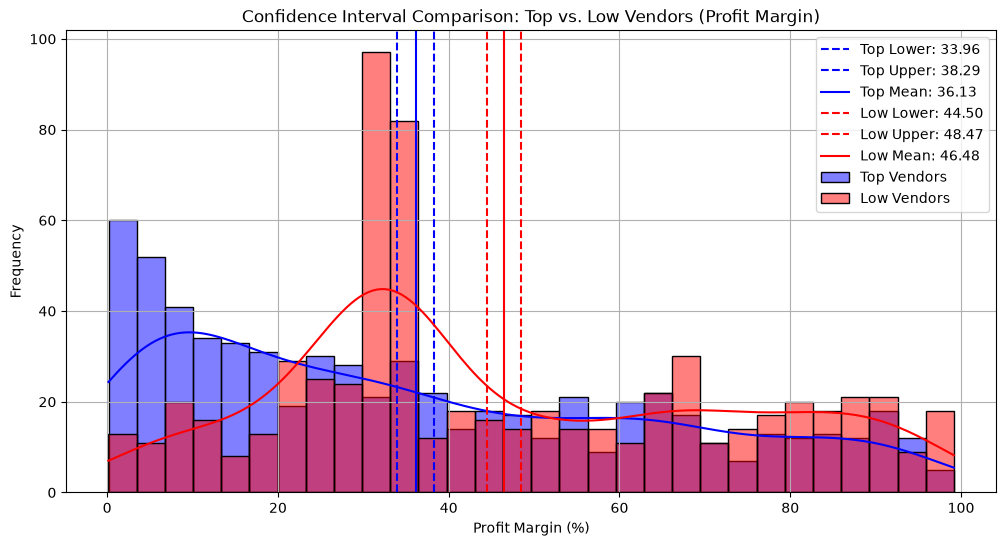

In [97]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(
    top_vendors,
    kde=True,
    color="blue",
    bins=30,
    alpha=0.5,
    label="Top Vendors"
)

plt.axvline(
    top_lower,
    color="blue",
    linestyle="--",
    label=f"Top Lower: {top_lower:.2f}"
)

plt.axvline(
    top_upper,
    color="blue",
    linestyle="--",
    label=f"Top Upper: {top_upper:.2f}"
)

plt.axvline(
    top_mean,
    color="blue",
    linestyle="-",
    label=f"Top Mean: {top_mean:.2f}"
)

# Low Vendors Plot
sns.histplot(
    low_vendors,
    kde=True,
    color="red",
    bins=30,
    alpha=0.5,
    label="Low Vendors"
)

plt.axvline(
    low_lower,
    color="red",
    linestyle="--",
    label=f"Low Lower: {low_lower:.2f}"
)

plt.axvline(
    low_upper,
    color="red",
    linestyle="--",
    label=f"Low Upper: {low_upper:.2f}"
)

plt.axvline(
    low_mean,
    color="red",
    linestyle="-",
    label=f"Low Mean: {low_mean:.2f}"
)

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

### Insights

* The confidence interval for **low-performing vendors (40.48% to 42.62%)** is significantly higher than that of **top-performing vendors (30.74% to 31.61%)**.
* This suggests that vendors with **lower sales tend to maintain higher profit margins**, potentially due to premium pricing or lower operational costs.
* **High-performing vendors:** To improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.
* **Low-performing vendors:** Despite having higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.


### Hypothesis

**H₀ (Null Hypothesis):** There is no significant difference in the mean profit margins between top-performing and low-performing vendors.

**H₁ (Alternative Hypothesis):** There is a significant difference in the mean profit margins between top-performing and low-performing vendors.


In [99]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")

T-Statistic: -6.9160, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.


In [100]:
df.to_csv("vendor_sales_summary.csv", index=False)

In [101]:
import os

print(os.path.abspath("vendor_sales_summary.csv"))

C:\Users\divya\vendor_sales_summary.csv
